# Load Libraries

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import onnxruntime as ort


# Get Char list

In [ ]:
# Vietnamese vowels grouped
vowel_groups = [
    "aàáảãạăằắẳẵặâầấẩẫậ",
    "eèéẻẽẹêềếểễệ",
    "iìíỉĩị",
    "oòóỏõọôồốổỗộơờớởỡợ",
    "uùúủũụưừứửữự",
    "yỳýỷỹỵ"
]

vietnamese_vowels = [c for group in vowel_groups for c in group]

vietnamese_consonants = list("bcdđghklmnpqrstvx")

digits = list("0123456789")

punctuation = list(" .,:;!?-_()[]\"'/%%&*=@$")

extra_chars = list("fjwzFJWZ#+")

# build char list
char_list = (
    vietnamese_vowels
    + vietnamese_consonants
    + [c.upper() for c in vietnamese_vowels]
    + [c.upper() for c in vietnamese_consonants]
    + digits
    + punctuation
    + extra_chars
)

# deduplicate + sort
char_list = sorted(set(char_list))

# index mapping
char_to_idx = {c: i for i, c in enumerate(char_list)}

print("Total characters:", len(char_list))

Total characters: 220


# Preprocess Img

In [16]:
def preprocess_image(img_path, target_height):
    # ======================
    # LOAD GRAYSCALE
    # ======================
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        return None, None

    h, w = img.shape

    # ======================
    # RESIZE (KEEP ASPECT)
    # ======================
    scale = target_height / h
    new_w = int(w * scale)
    img = cv2.resize(img, (new_w, target_height))

    # ======================
    # SHADOW REMOVAL
    # ======================
    background = cv2.medianBlur(img, 31)
    img = cv2.divide(img, background, scale=255)

    # ======================
    # 90% INTENSITY FILTER
    # ======================
    max_val = np.max(img)
    img = np.where(img >= 0.9 * max_val, 255, img).astype(np.uint8)

    # ======================
    # CLAHE
    # ======================
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    img = clahe.apply(img)

    # ======================
    # ADAPTIVE THRESHOLD
    # ======================
    bw = cv2.adaptiveThreshold(
        img,
        255,
        cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
        cv2.THRESH_BINARY_INV,
        31,
        10
    )

    # ======================
    # REMOVE ISOLATED PIXELS
    # ======================
    bw_bin = (bw > 0).astype(np.uint8)

    neighbor_count = cv2.filter2D(
        bw_bin,
        -1,
        np.ones((3, 3), np.uint8)
    )

    isolated = (bw_bin == 1) & (neighbor_count <= 2)

    clean = bw.copy()
    clean[isolated] = 0

    # ======================
    # NORMALIZE & EXPAND
    # ======================
    img = clean.astype(np.float32) / 255.0
    img = np.expand_dims(img, axis=2)
    img = np.expand_dims(img, axis=0)
    return img

# Predict Func

In [17]:
def get_pred(img, onnx_path):
    sess = ort.InferenceSession(onnx_path, providers=["CPUExecutionProvider"])

    input_name = sess.get_inputs()[0].name
    output_name = sess.get_outputs()[0].name

    pred = sess.run(
        [output_name],
        {input_name: img.astype(np.float32)}
    )[0]
    blank_idx = len(char_list)

    def ctc_greedy_decode(pred):
        # pred: (T, num_classes)
        best_path = np.argmax(pred, axis=-1)

        text = []
        prev = -1
        for p in best_path:
            if p != prev and p != blank_idx:
                text.append(char_list[p])
            prev = p
        return "".join(text)

    text = ctc_greedy_decode(pred[0])
    # print("Predicted text:", text)
    return text, pred

In [18]:
# text, pre = get_pred(preprocess_image("3.jpg", debug=True))
# print(text)

In [19]:
def ctc_greedy_decode_with_char_conf(pred):
    best_path = np.argmax(pred, axis=-1)
    best_probs = np.max(pred, axis=-1)

    text = []
    char_confidences = []
    prev = -1
    
    blank_idx = len(char_list)

    for i, p in enumerate(best_path):
        if p != prev and p != blank_idx:
            char = char_list[p]
            prob = best_probs[i] * 100  # convert to %
            text.append(char)
            char_confidences.append(prob)
        prev = p

    return "".join(text), char_confidences

# Test

In [20]:
onnx_path = "D:\\FPT\\DAT\\crnn_inference(7).onnx"

In [52]:
img_path ="D:\\FPT\\DAT\\test\\images\\1.jpg"

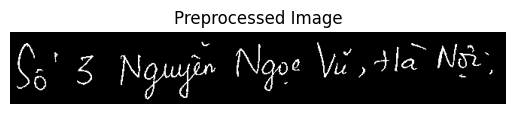

In [53]:
img = preprocess_image(img_path, 96)   # shape: (1, H, W, 1)

plt.imshow(img[0, :, :, 0], cmap='gray')
plt.title("Preprocessed Image")
plt.axis("off")
plt.show()

In [54]:
text, pre = get_pred(img, onnx_path)
text, char_confs = ctc_greedy_decode_with_char_conf(pre[0])

print("Predicted text:", text)

for c, conf in zip(text, char_confs):
    print(f"{c}: {conf:.2f}%")

Predicted text: Số 3 Nguyễn Ngọc Vũ, Hà Nội
S: 99.99%
ố: 96.99%
 : 99.34%
3: 84.75%
 : 99.70%
N: 99.98%
g: 57.81%
u: 88.14%
y: 99.98%
ễ: 99.99%
n: 100.00%
 : 99.68%
N: 100.00%
g: 99.99%
ọ: 99.86%
c: 95.97%
 : 99.73%
V: 99.98%
ũ: 96.98%
,: 93.72%
 : 100.00%
H: 99.98%
à: 99.99%
 : 99.98%
N: 99.99%
ộ: 100.00%
i: 86.27%
